# Diffusion Models

This notebook is designed for the **session on Diffusion models** in **Uncertainty Evaluation in Engineering Measurements and Machine Learning** course at the **University of Ottawa (Winter 2026)**.

It mirrors the *teaching intent* of compact, concept-first notebooks: short explanations, small runnable cells, and figures that can be reused in slides. The code is original and CPU-friendly, but the structure was inspired by the educational style of the course notebooks, Hugging Face diffusion tutorials, and `pyprobml`. The course repo emphasizes practical Python notebooks alongside lecture material, and the `diffusers` project is positioned as a modular toolbox for state-of-the-art diffusion models; `pyprobml` similarly uses concise notebooks to reproduce probabilistic ML ideas with standard Python tools.

## Learning goals

By the end of this notebook, students should be able to:

1. explain the **score** and **Langevin dynamics** intuition,
2. visualize the **forward diffusion** process,
3. understand the **DDPM denoising objective**,
4. see how **reverse sampling** gradually builds a sample from noise,
5. understand why **conditional diffusion** is useful for time series, and
6. discuss the **speed–quality tradeoff** in fast samplers.

## Runtime and dependencies

- CPU only
- runtime target: **well under 2 minutes**
- libraries used: **numpy, matplotlib, scikit-learn** (plus standard library helpers)

## Figures saved for slides

This notebook writes reusable figures into `generated_figures/`:

- `story_diffusion_strip.png`
- `score_langevin.png`
- `forward_noising_moons.png`
- `ddpm_training_curve.png`
- `reverse_sampling_strip.png`
- `time_series_samples.png`
- `speed_quality_tradeoff.png`
- `notebook_figure_montage.png`

In [10]:
import math
import time
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.exceptions import ConvergenceWarning

SEED = 7
np.random.seed(SEED)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 150,
    "axes.grid": True,
    "font.size": 11,
})

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

def savefig(name, fig=None):
    fig = plt.gcf() if fig is None else fig
    path = FIG_DIR / name
    fig.tight_layout()
    fig.savefig(path, bbox_inches="tight")
    print(f"saved: {path}")
    return path

rng = np.random.default_rng(SEED)

## 1) Score intuition: follow the density gradient

For a density $p(x)$, the **score** is

$\nabla_x \log p(x).$

It points toward directions where the log-density increases most rapidly.

A very clean classroom demo is to use a **known 2D Gaussian mixture**, compute its score analytically, and then run **Langevin dynamics**

$x_{k+1} = x_k + \eta \nabla_x \log p(x_k) + \sqrt{2\eta}\,z_k,
\qquad z_k \sim \mathcal N(0, I).
$

The green arrows below are the score field. The colored curves are Langevin trajectories that drift toward high-density regions while still keeping some randomness.

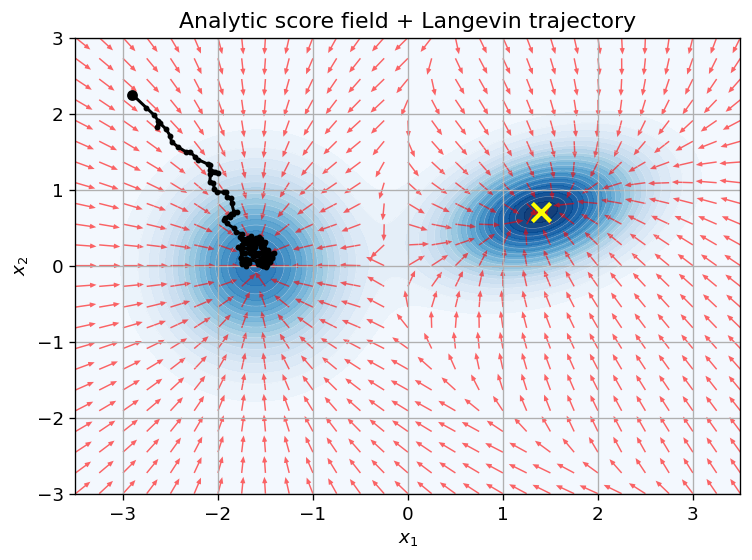

In [11]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

means = np.array([[-1.6, 0.0], [1.4, 0.7]])
covs = np.array([
    [[0.35, 0.0], [0.0, 0.55]],
    [[0.45, 0.12], [0.12, 0.28]],
])
weights = np.array([0.5, 0.5])

inv_covs = np.linalg.inv(covs)
dets = np.linalg.det(covs)

def comp_pdf(x, mean, cov_inv, det):
    d = x - mean
    expo = -0.5 * np.einsum("...i,ij,...j->...", d, cov_inv, d)
    return np.exp(expo) / (2 * np.pi * np.sqrt(det))

def mixture_density(x):
    out = np.zeros(x.shape[:-1])
    for w, m, cinv, det in zip(weights, means, inv_covs, dets):
        out += w * comp_pdf(x, m, cinv, det)
    return out

def mixture_score(x):
    x = np.asarray(x)
    comp_probs = []
    comp_grads = []
    for w, m, cinv, det in zip(weights, means, inv_covs, dets):
        p = w * comp_pdf(x, m, cinv, det)
        grad_log = -(x - m) @ cinv.T
        comp_probs.append(p)
        comp_grads.append(grad_log)
    comp_probs = np.stack(comp_probs, axis=-1)
    comp_grads = np.stack(comp_grads, axis=-2)
    denom = np.sum(comp_probs, axis=-1, keepdims=True) + 1e-12
    return np.sum(comp_probs[..., None] * comp_grads, axis=-2) / denom

def langevin_chain(x0, eta=0.03, steps=110, noise_scale=0.35, seed=7):
    rng = np.random.default_rng(seed)
    x = np.array(x0, dtype=float)
    chain = [x.copy()]
    for _ in range(steps):
        drift = eta * mixture_score(x[None, :])[0]
        noise = noise_scale * np.sqrt(2 * eta) * rng.normal(size=2)
        x = x + drift + noise
        chain.append(x.copy())
    return np.array(chain)

# Dense grid for background density
x1 = np.linspace(-3.5, 3.5, 220)
x2 = np.linspace(-3.0, 3.0, 180)
Xg, Yg = np.meshgrid(x1, x2)
grid = np.stack([Xg, Yg], axis=-1)
density = mixture_density(grid)

# Slightly coarser but still dense grid for arrows
xq = np.linspace(-3.5, 3.5, 29)
yq = np.linspace(-3.0, 3.0, 23)
Xq, Yq = np.meshgrid(xq, yq)
qgrid = np.stack([Xq, Yq], axis=-1)
score = mixture_score(qgrid)

# Normalize arrows for a cleaner, denser field
norm = np.linalg.norm(score, axis=-1, keepdims=True) + 1e-12
score_unit = score / norm

chain = langevin_chain(
    x0=(-2.9, 2.25),
    eta=0.02,
    steps=140,
    noise_scale=0.18,
    seed=3
)

fig, ax = plt.subplots(figsize=(6.4, 4.8))

# Filled density background
ax.contourf(Xg, Yg, density, levels=28, cmap="Blues", alpha=0.95)
ax.contour(Xg, Yg, density, levels=12, colors="white", linewidths=0.35, alpha=0.5)

# Dense score field
ax.quiver(
    Xq, Yq,
    score_unit[..., 0], score_unit[..., 1],
    color="red",
    alpha=0.6,
    angles="xy",
    scale_units="xy",
    scale=4.5,
    width=0.0022,
    headwidth=3.5,
    headlength=4.2
)

# Langevin trajectory
ax.plot(chain[:, 0], chain[:, 1], color="black", linewidth=1.8, marker="o", markersize=2.5)
ax.scatter(chain[0, 0], chain[0, 1], color="black", s=30, zorder=4)

# Highlight one mode
ax.scatter(means[1, 0], means[1, 1], marker="x", s=120, linewidths=2.5, color="yellow", zorder=5)

ax.set_title("Analytic score field + Langevin trajectory")
ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$x_2$")
ax.set_xlim(-3.5, 3.5)
ax.set_ylim(-3.0, 3.0)

fig.tight_layout()
fig.savefig(FIG_DIR / "score_langevin.png", dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)

## 2) The diffusion story in one picture

The most memorable high-level story is:

1. start from clean data $x_0$,
2. add small Gaussian perturbations until the sample looks almost Gaussian,
3. learn a model that can reverse those perturbations,
4. start from noise and repeatedly denoise.

We first visualize the **forward process** on a toy two-moons dataset because it is easy to interpret.

saved: figures/story_diffusion_strip.png


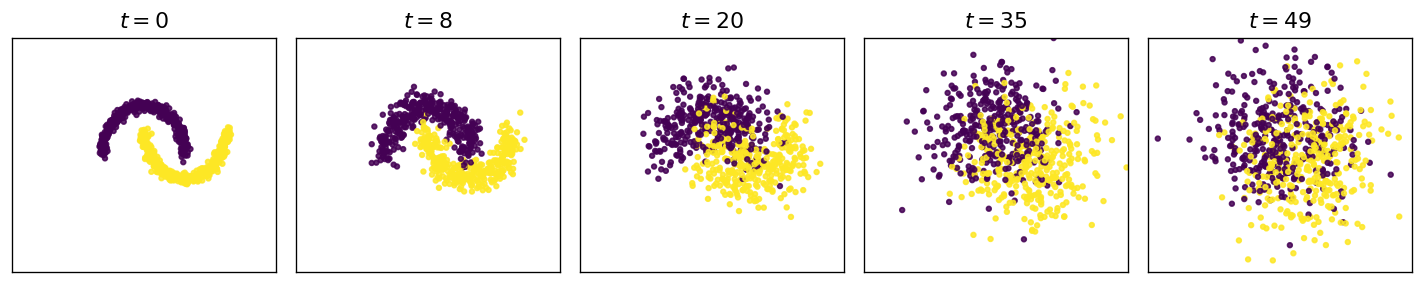

saved: figures/forward_noising_moons.png


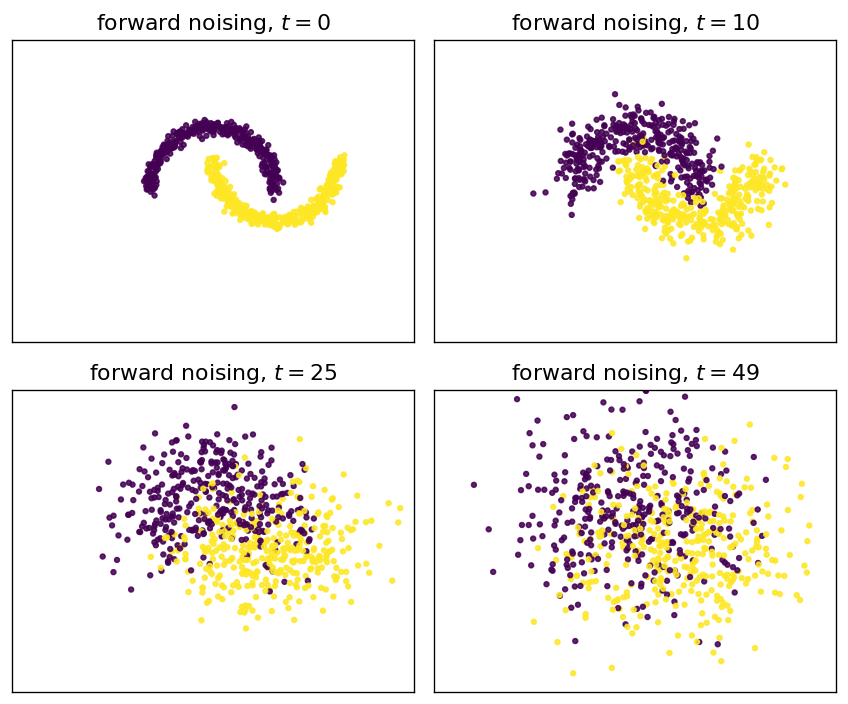

In [12]:
X, y = make_moons(n_samples=700, noise=0.06, random_state=2)

T = 50
beta = np.linspace(1e-4, 0.03, T)
alpha = 1.0 - beta
alphabar = np.cumprod(alpha)

story_steps = [0, 8, 20, 35, 49]
fig, axes = plt.subplots(1, 5, figsize=(12, 2.5))
for ax, t in zip(axes, story_steps):
    Xt = np.sqrt(alphabar[t]) * X + np.sqrt(1 - alphabar[t]) * rng.normal(size=X.shape)
    ax.scatter(Xt[:, 0], Xt[:, 1], c=y, s=8, alpha=0.85)
    ax.set_title(f"$t={t}$")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim(-3.2, 3.2)
    ax.set_ylim(-2.4, 2.4)
savefig("story_diffusion_strip.png")
plt.show();
plt.close()

fig, axes = plt.subplots(2, 2, figsize=(7.2, 6))
for ax, t in zip(axes.ravel(), [0, 10, 25, 49]):
    Xt = np.sqrt(alphabar[t]) * X + np.sqrt(1 - alphabar[t]) * rng.normal(size=X.shape)
    ax.scatter(Xt[:, 0], Xt[:, 1], c=y, s=8, alpha=0.85)
    ax.set_title(f"forward noising, $t={t}$")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim(-3.2, 3.2)
    ax.set_ylim(-2.4, 2.4)
savefig("forward_noising_moons.png")
plt.show();
plt.close()

## 3) Minimal DDPM training objective on a toy dataset

For DDPM, the forward process is

$q(x_t \mid x_{t-1}) = \mathcal N(\sqrt{1-\beta_t}\,x_{t-1}, \beta_t I).
$

This gives the useful closed form

$x_t = \sqrt{\bar\alpha_t}x_0 + \sqrt{1-\bar\alpha_t}\,\epsilon,
\qquad \epsilon \sim \mathcal N(0, I).
$

The standard simplified training loss is

$\mathcal L_{\text{simple}}(\theta)
= \mathbb E_{t, x_0, \epsilon}
\left[
\|\epsilon - \epsilon_\theta(x_t, t)\|_2^2
\right].
$

Below, we train a **tiny MLP denoiser** on 2D two-moons data. This is not for image-quality generation; it is only a compact demonstration of the DDPM idea.

2D denoiser training time: 21.73 s
number of epochs used: 85
saved: figures/ddpm_training_curve.png


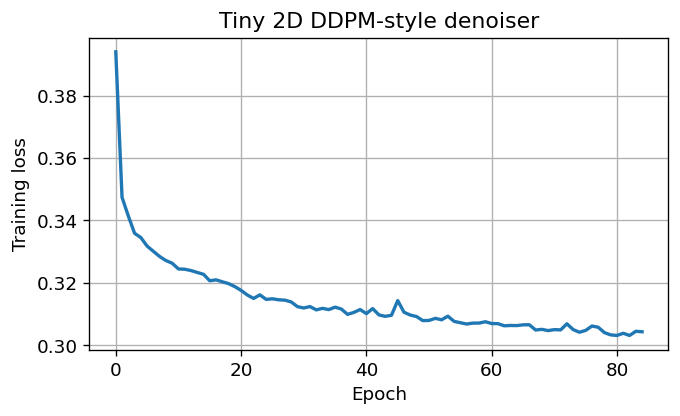

In [13]:
X_train, _ = make_moons(n_samples=900, noise=0.06, random_state=3)

N = 4500
idx = rng.integers(0, len(X_train), size=N)
t_idx = rng.integers(0, T, size=N)
eps = rng.normal(size=(N, 2))

X_t = np.sqrt(alphabar[t_idx, None]) * X_train[idx] + np.sqrt(1 - alphabar[t_idx, None]) * eps

features = np.column_stack([
    X_t,
    np.sin(2 * np.pi * (t_idx + 1) / T),
    np.cos(2 * np.pi * (t_idx + 1) / T),
    (t_idx + 1) / T,
])
targets = eps

t0 = time.time()
eps_model = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPRegressor(
        hidden_layer_sizes=(64, 64),
        activation="tanh",
        max_iter=150,
        random_state=SEED,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=10,
    )),
])
eps_model.fit(features, targets)
train_time_2d = time.time() - t0

loss_curve = eps_model.named_steps["mlp"].loss_curve_
print(f"2D denoiser training time: {train_time_2d:.2f} s")
print(f"number of epochs used: {len(loss_curve)}")

plt.figure(figsize=(5.8, 3.6))
plt.plot(loss_curve, lw=2)
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("Tiny 2D DDPM-style denoiser")
savefig("ddpm_training_curve.png")
plt.show();
plt.close()

## 3b) Algorithmic steps: DDPM training and inference

### DDPM training
1. Sample a clean training example $x_0$.
2. Sample a timestep $t$ uniformly.
3. Sample Gaussian noise $\epsilon \sim \mathcal N(0,I)$.
4. Form a noisy point
   $$x_t = \sqrt{\bar\alpha_t}\,x_0 + \sqrt{1-\bar\alpha_t}\,\epsilon.$$
5. Predict the injected noise with the denoiser $\epsilon_\theta(x_t,t)$.
6. Minimize the mean-squared error between the true and predicted noise.

### DDPM inference
1. Start from pure noise $x_T \sim \mathcal N(0,I)$.
2. For $t=T,T-1,\ldots,1$, evaluate the denoiser.
3. Compute the reverse-step mean from the predicted noise.
4. Optionally add Gaussian noise for stochastic sampling.
5. Return the final denoised sample $x_0$.

This is the core training/inference loop behind the lecture and the toy implementation in this notebook.


## 4) Reverse sampling from the learned denoiser

Once we have a noise predictor $\epsilon_\theta(x_t, t)$, a simple ancestral reverse update is

$
x_{t-1}
=
\frac{1}{\sqrt{\alpha_t}}
\left(
x_t - \frac{1-\alpha_t}{\sqrt{1-\bar\alpha_t}}\,
\epsilon_\theta(x_t, t)
\right)
+
\sigma_t z,
\qquad z \sim \mathcal N(0, I).
$

In words:

- start from $x_T \sim \mathcal N(0, I)$,
- predict the noise at the current step,
- move to a cleaner sample,
- repeat until $t=0$.

The next figure shows several reverse snapshots.

saved: figures/reverse_sampling_strip.png


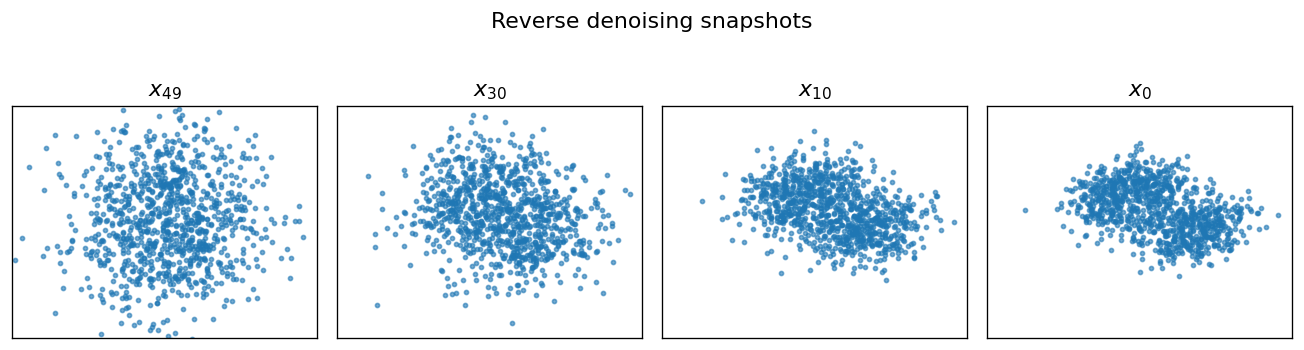

In [14]:
def predict_eps(model, x, t_scalar):
    x = np.asarray(x)
    tt = np.full((len(x),), t_scalar)
    feat = np.column_stack([
        x,
        np.sin(2 * np.pi * (tt + 1) / T),
        np.cos(2 * np.pi * (tt + 1) / T),
        (tt + 1) / T,
    ])
    return model.predict(feat)

def reverse_sample_2d(model, n=1000, seed=0, stride=1, snapshot_ts=(49, 30, 10, 0)):
    rng = np.random.default_rng(seed)
    x = rng.normal(size=(n, 2))
    steps = list(range(T - 1, -1, -stride))
    if steps[-1] != 0:
        steps.append(0)
    snapshots = []
    for t in steps:
        eps_hat = predict_eps(model, x, t)
        mean = (x - (1 - alpha[t]) / np.sqrt(1 - alphabar[t]) * eps_hat) / np.sqrt(alpha[t])
        x = mean if t == 0 else mean + np.sqrt(beta[t]) * rng.normal(size=x.shape)
        if t in snapshot_ts:
            snapshots.append((t, x.copy()))
    if snapshots[-1][0] != 0:
        snapshots.append((0, x.copy()))
    snapshots = sorted({t: arr for t, arr in snapshots}.items(), reverse=True)
    return x, snapshots

samples_2d, snapshots = reverse_sample_2d(eps_model, seed=3)

fig, axes = plt.subplots(1, len(snapshots), figsize=(11, 2.8))
for ax, (t, arr) in zip(axes, snapshots):
    ax.scatter(arr[:, 0], arr[:, 1], s=6, alpha=0.6, c="tab:blue")
    ax.set_title(f"$x_{{{t}}}$")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim(-3.2, 3.2)
    ax.set_ylim(-2.4, 2.4)
plt.suptitle("Reverse denoising snapshots", y=1.03)
savefig("reverse_sampling_strip.png")
plt.show();
plt.close()

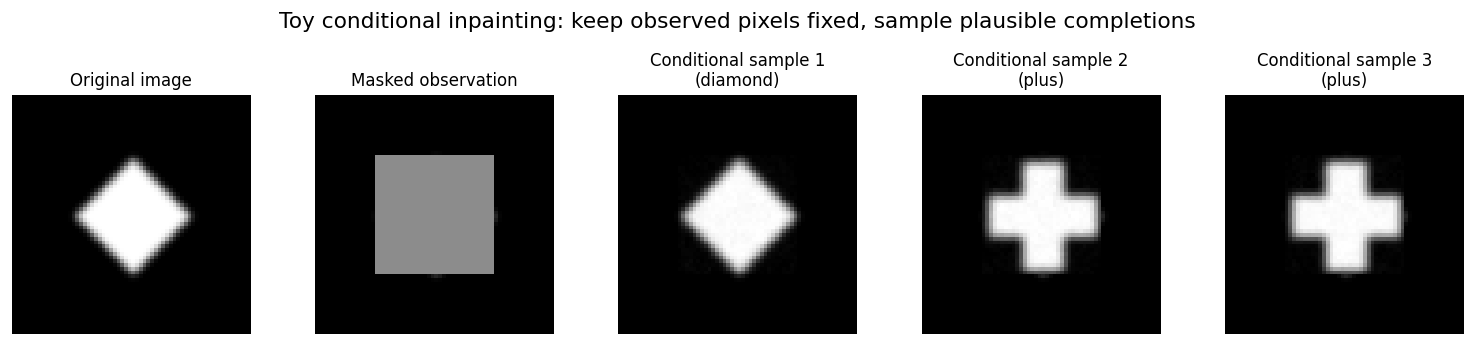

Saved: /content/figures/conditional_inpainting_demo.png
Template probabilities from visible pixels only:
  circle  : 0.250
  square  : 0.250
  diamond : 0.250
  plus    : 0.250


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# Toy conditional diffusion / inpainting demo
# - CPU-friendly
# - deterministic
# - uses only numpy + matplotlib
# - produces a slide-ready figure:
#   original | masked observation | 3 plausible conditional samples
# ============================================================

# ----------------------------
# Reproducibility
# ----------------------------
SEED = 7
rng = np.random.default_rng(SEED)

# ----------------------------
# Output directory
# ----------------------------
FIG_DIR = Path("figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ----------------------------
# Small image utilities
# ----------------------------
H, W = 64, 64
yy, xx = np.mgrid[0:H, 0:W]
cy, cx = H / 2, W / 2

def normalize01(x):
    x = x - x.min()
    x = x / (x.max() + 1e-12)
    return x

def blur2d(img, passes=1):
    """Simple 3x3 smoothing using only numpy."""
    k = np.array([[1, 2, 1],
                  [2, 4, 2],
                  [1, 2, 1]], dtype=float)
    k /= k.sum()
    out = img.copy()
    for _ in range(passes):
        p = np.pad(out, ((1, 1), (1, 1)), mode="reflect")
        out = (
            k[0,0]*p[:-2, :-2] + k[0,1]*p[:-2, 1:-1] + k[0,2]*p[:-2, 2:] +
            k[1,0]*p[1:-1, :-2] + k[1,1]*p[1:-1, 1:-1] + k[1,2]*p[1:-1, 2:] +
            k[2,0]*p[2:, :-2] + k[2,1]*p[2:, 1:-1] + k[2,2]*p[2:, 2:]
        )
    return out

# ----------------------------
# Create a small library of centered shapes
# (all mostly inside the missing region, so multiple completions
# can be consistent with the visible pixels)
# ----------------------------
def soft_circle(radius=12):
    r = np.sqrt((xx - cx)**2 + (yy - cy)**2)
    img = (r <= radius).astype(float)
    return blur2d(img, passes=2)

def soft_square(half=11):
    img = ((np.abs(xx - cx) <= half) & (np.abs(yy - cy) <= half)).astype(float)
    return blur2d(img, passes=2)

def soft_diamond(radius=15):
    img = ((np.abs(xx - cx) + np.abs(yy - cy)) <= radius).astype(float)
    return blur2d(img, passes=2)

def soft_plus(thick=5, arm=14):
    img = (
        ((np.abs(xx - cx) <= thick) & (np.abs(yy - cy) <= arm)) |
        ((np.abs(yy - cy) <= thick) & (np.abs(xx - cx) <= arm))
    ).astype(float)
    return blur2d(img, passes=2)

templates = {
    "circle": normalize01(soft_circle(radius=12)),
    "square": normalize01(soft_square(half=11)),
    "diamond": normalize01(soft_diamond(radius=15)),
    "plus": normalize01(soft_plus(thick=5, arm=14)),
}

# ----------------------------
# Choose one "true" image
# ----------------------------
true_name = "diamond"
x_true = templates[true_name]

# ----------------------------
# Define observed / missing mask
#   mask = 1  -> observed pixels
#   mask = 0  -> missing pixels
# ----------------------------
mask = np.ones((H, W), dtype=float)
mask[16:48, 16:48] = 0.0   # hide the center block

# Visualization version of masked observation
# Show missing region in gray so students can see the mask
x_obs_vis = x_true.copy()
x_obs_vis[mask == 0] = 0.55

# Numeric observation used by the toy conditional sampler
# Only observed pixels are enforced
x_obs = x_true * mask

# ----------------------------
# Candidate probabilities from visible region only
# (a tiny analogy to conditioning: keep what is observed fixed,
# complete the missing region in a plausible way)
# ----------------------------
scores = []
names = list(templates.keys())
for name in names:
    tmpl = templates[name]
    mse = np.mean(((tmpl - x_obs) * mask) ** 2)
    scores.append(mse)

scores = np.array(scores)
# Convert MSE to a soft probability over candidate completions
probs = np.exp(-35.0 * scores)
probs = probs / probs.sum()

# ----------------------------
# Toy "conditional reverse process"
# Not a trained diffusion model; just a lightweight visual analogy:
# - start from noise
# - repeatedly denoise toward a sampled template
# - enforce observed pixels at every step
# ----------------------------
def conditional_sample(observed, mask, template, seed=0, steps=35):
    local_rng = np.random.default_rng(seed)

    # start from noisy image
    x = local_rng.normal(loc=0.5, scale=0.35, size=observed.shape)
    x = np.clip(x, 0.0, 1.0)
    x[mask == 1] = observed[mask == 1]  # keep visible pixels fixed

    for t in range(steps):
        frac = t / max(steps - 1, 1)

        # decrease randomness over time
        sigma = 0.16 * (1.0 - frac)

        # simple denoising / guidance toward the chosen template
        smoothed = blur2d(x, passes=1)
        x = 0.62 * x + 0.18 * smoothed + 0.20 * template

        # stochasticity only in the missing region
        noise = sigma * local_rng.normal(size=x.shape)
        x = x + noise * (1.0 - mask)

        # enforce observed pixels after every reverse step
        x[mask == 1] = observed[mask == 1]
        x = np.clip(x, 0.0, 1.0)

    return x

# Draw three conditional samples
# We sample templates according to visible-pixel consistency
sampled_templates = rng.choice(names, size=3, replace=True, p=probs)
samples = []
for i, name in enumerate(sampled_templates):
    samp = conditional_sample(
        observed=x_obs,
        mask=mask,
        template=templates[name],
        seed=SEED + 10 + i,
        steps=35
    )
    samples.append((name, samp))

# ----------------------------
# Plot
# ----------------------------
fig, axes = plt.subplots(1, 5, figsize=(12.8, 2.8))

panels = [
    ("Original image", x_true),
    ("Masked observation", x_obs_vis),
    (f"Conditional sample 1\n({samples[0][0]})", samples[0][1]),
    (f"Conditional sample 2\n({samples[1][0]})", samples[1][1]),
    (f"Conditional sample 3\n({samples[2][0]})", samples[2][1]),
]

for ax, (title, img) in zip(axes, panels):
    ax.imshow(img, cmap="gray", vmin=0, vmax=1)
    ax.set_title(title, fontsize=10)
    ax.axis("off")

fig.suptitle(
    "Toy conditional inpainting: keep observed pixels fixed, sample plausible completions",
    fontsize=13,
    y=1.02
)

fig.tight_layout()

out_path = FIG_DIR / "conditional_inpainting_demo.png"
fig.savefig(out_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Saved: {out_path.resolve()}")
print("Template probabilities from visible pixels only:")
for name, p in zip(names, probs):
    print(f"  {name:8s}: {p:.3f}")

## 4b) Algorithmic steps: conditional diffusion (inpainting)

### Training
1. Sample a clean target image $x_0$ and a condition $c$ (here: observed pixels and a mask).
2. Sample a timestep $t$ and Gaussian noise $\epsilon$.
3. Form the noisy state $x_t$.
4. Train a conditional denoiser $\epsilon_\theta(x_t,t,c)$.

### Inference
1. Keep the observed pixels fixed and initialize the missing region from noise.
2. For $t=T,\dots,1$, denoise using the condition $c$.
3. After each step, re-impose the observed pixels.
4. Repeat multiple times to get different plausible completions.

The key uncertainty message is that conditioning narrows the distribution, but does not have to collapse it to one single answer.


## 5) Conditional diffusion for time series: sample-based forecasting intuition

For signals and time series, we care about **conditional distributions**

$p_\theta(x_{\text{future}} \mid x_{\text{past}}, c).
$

The important uncertainty lesson is that the output should be a **distribution of plausible futures**, not only a single forecast.

To keep the notebook lightweight, we use a synthetic dataset of smooth signals and train a tiny conditional denoiser for the future segment conditioned on the observed past segment.

time-series conditional denoiser training time: 7.55 s
saved: figures/time_series_samples.png


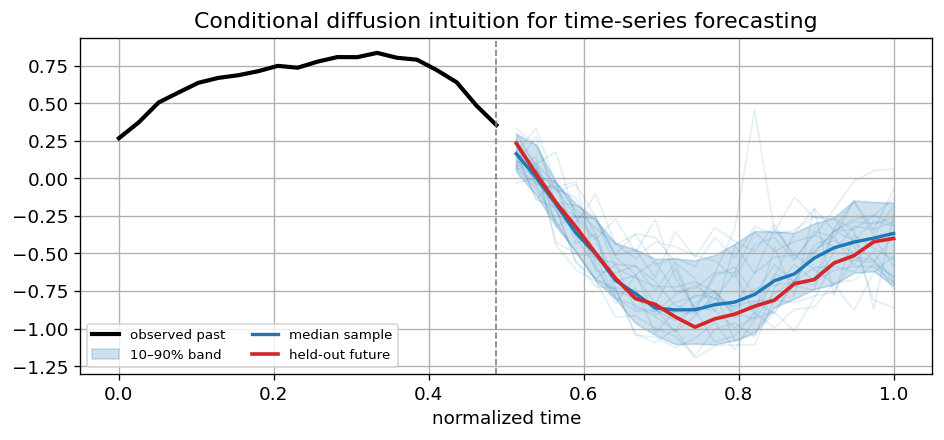

In [16]:
P, H = 20, 20
T_ts = 40
beta_ts = np.linspace(1e-4, 0.03, T_ts)
alpha_ts = 1.0 - beta_ts
alphabar_ts = np.cumprod(alpha_ts)

def make_signal_bank(n, seed=0):
    rng = np.random.default_rng(seed)
    t = np.linspace(0, 1, P + H)
    out = []
    for _ in range(n):
        a1 = 0.9 + 0.12 * rng.normal()
        a2 = 0.18 + 0.05 * rng.normal()
        f1 = 0.9 + 0.08 * rng.normal()
        f2 = 2.1 + 0.12 * rng.normal()
        ph1 = rng.uniform(-0.08, 0.08)
        ph2 = rng.uniform(-0.10, 0.10)
        trend = 0.08 * rng.normal() * (t - 0.5)
        y = a1 * np.sin(2 * np.pi * (f1 * t + ph1))
        y += a2 * np.cos(2 * np.pi * (f2 * t + ph2))
        y += trend + 0.02 * rng.normal(size=len(t))
        out.append(y)
    return np.array(out), t

signal_bank, t_axis = make_signal_bank(1400, seed=11)
past_bank = signal_bank[:, :P]
future_bank = signal_bank[:, P:]

N_ts = 2600
idx = rng.integers(0, len(signal_bank), size=N_ts)
t_idx = rng.integers(0, T_ts, size=N_ts)
eps = rng.normal(size=(N_ts, H))

future_t = np.sqrt(alphabar_ts[t_idx, None]) * future_bank[idx] + np.sqrt(1 - alphabar_ts[t_idx, None]) * eps

features_ts = np.concatenate([
    past_bank[idx],
    future_t,
    np.sin(2 * np.pi * (t_idx + 1) / T_ts)[:, None],
    np.cos(2 * np.pi * (t_idx + 1) / T_ts)[:, None],
    ((t_idx + 1) / T_ts)[:, None],
], axis=1)
targets_ts = eps

t0 = time.time()
ts_model = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPRegressor(
        hidden_layer_sizes=(80, 80),
        activation="tanh",
        max_iter=120,
        random_state=SEED,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=10,
    )),
])
ts_model.fit(features_ts, targets_ts)
train_time_ts = time.time() - t0
print(f"time-series conditional denoiser training time: {train_time_ts:.2f} s")

def predict_eps_ts(model, past_obs, future_state, t_scalar):
    n = len(future_state)
    tt = np.full((n,), t_scalar)
    past_rep = np.repeat(np.asarray(past_obs)[None, :], n, axis=0)
    feat = np.concatenate([
        past_rep,
        future_state,
        np.sin(2 * np.pi * (tt + 1) / T_ts)[:, None],
        np.cos(2 * np.pi * (tt + 1) / T_ts)[:, None],
        ((tt + 1) / T_ts)[:, None],
    ], axis=1)
    return model.predict(feat)

def sample_future_paths(model, past_obs, n_samples=80, seed=0):
    rng = np.random.default_rng(seed)
    x = rng.normal(size=(n_samples, H))
    for t in range(T_ts - 1, -1, -1):
        eps_hat = predict_eps_ts(model, past_obs, x, t)
        mean = (x - (1 - alpha_ts[t]) / np.sqrt(1 - alphabar_ts[t]) * eps_hat) / np.sqrt(alpha_ts[t])
        x = mean if t == 0 else mean + np.sqrt(beta_ts[t]) * rng.normal(size=x.shape)
    return x

test_signal, t_axis = make_signal_bank(1, seed=99)
past_obs = test_signal[0, :P]
true_future = test_signal[0, P:]
sampled_futures = sample_future_paths(ts_model, past_obs, n_samples=80, seed=4)

lo = np.percentile(sampled_futures, 10, axis=0)
hi = np.percentile(sampled_futures, 90, axis=0)
med = np.median(sampled_futures, axis=0)

plt.figure(figsize=(8, 3.8))
plt.plot(t_axis[:P], past_obs, color="black", lw=2.5, label="observed past")
for s in sampled_futures[:20]:
    plt.plot(t_axis[P:], s, color="tab:blue", alpha=0.12, lw=1)
plt.fill_between(t_axis[P:], lo, hi, color="tab:blue", alpha=0.22, label="10–90% band")
plt.plot(t_axis[P:], med, color="tab:blue", lw=2, label="median sample")
plt.plot(t_axis[P:], true_future, color="tab:red", lw=2.2, label="held-out future")
plt.axvline(t_axis[P - 1], color="gray", ls="--", lw=1)
plt.title("Conditional diffusion intuition for time-series forecasting")
plt.xlabel("normalized time")
plt.legend(ncol=2, fontsize=8, loc="lower left")
savefig("time_series_samples.png")
plt.show();
plt.close()

## 5b) Algorithmic steps: conditional diffusion for forecasting

### Training
1. Split each signal into observed past and future target segments.
2. Sample a timestep $t$ and Gaussian noise for the future segment.
3. Corrupt only the future segment and condition on the past segment.
4. Train the denoiser to predict the injected future noise.

### Inference
1. Keep the past segment fixed.
2. Initialize the future segment from Gaussian noise.
3. Iteratively denoise the future while conditioning on the observed past.
4. Draw multiple futures to represent predictive uncertainty.

This is the basic logic behind diffusion forecasting and imputation models such as TimeGrad and CSDI.


## 5c) Algorithmic steps: latent diffusion

### Training
1. Encode a data sample $x$ into a latent code $z_0 = E(x)$ using an autoencoder.
2. Add Gaussian noise in latent space to obtain $z_t$.
3. Train a latent denoiser to predict the injected noise or the clean latent.
4. Keep the decoder available to map final latent samples back to data space.

### Inference
1. Start from latent noise $z_T \sim \mathcal N(0,I)$.
2. Run reverse diffusion in the lower-dimensional latent space.
3. Decode the final latent sample with $\hat x = D(z_0)$.

The main advantage is computational: reverse diffusion runs in a compressed space rather than directly on full-resolution pixels.


## 6) Fast sampling: the speed–quality tradeoff

A central practical question is: **how many reverse steps do we really need?**

We use the tiny 2D model and compare several stride values. As a very lightweight quality proxy, we use an RBF-kernel **MMD** against reference two-moons samples.

This is not a production benchmark; it is just enough to show the classroom point that **fewer steps are faster, but quality usually drops**.

saved: figures/speed_quality_tradeoff.png


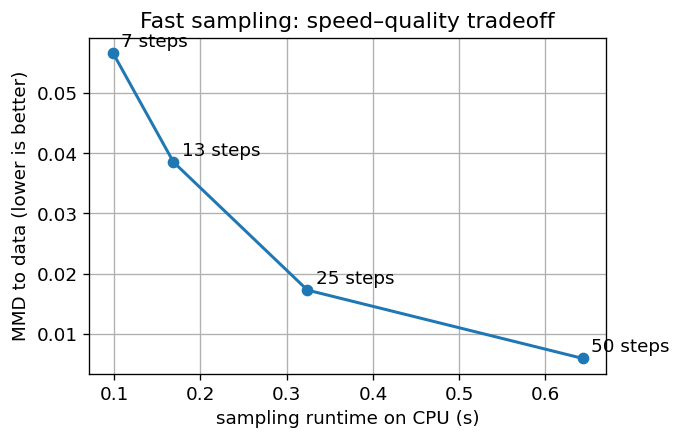

In [17]:
def mmd_rbf(X, Y, gamma=0.7):
    Kxx = rbf_kernel(X, X, gamma=gamma)
    Kyy = rbf_kernel(Y, Y, gamma=gamma)
    Kxy = rbf_kernel(X, Y, gamma=gamma)
    n, m = len(X), len(Y)
    return Kxx.sum() / (n * n) + Kyy.sum() / (m * m) - 2 * Kxy.sum() / (n * m)

ref, _ = make_moons(n_samples=900, noise=0.06, random_state=123)

strides = [1, 2, 4, 8]
runtimes = []
qualities = []
steps_used = []

for stride in strides:
    t0 = time.time()
    gen, _ = reverse_sample_2d(eps_model, n=900, seed=5, stride=stride)
    runtimes.append(time.time() - t0)
    qualities.append(mmd_rbf(gen, ref, gamma=0.7))
    steps_used.append(math.ceil(T / stride))

plt.figure(figsize=(5.8, 3.8))
plt.plot(runtimes, qualities, marker="o", lw=1.8)
for x, y, st in zip(runtimes, qualities, steps_used):
    plt.annotate(f"{st} steps", (x, y), textcoords="offset points", xytext=(5, 4))
plt.xlabel("sampling runtime on CPU (s)")
plt.ylabel("MMD to data (lower is better)")
plt.title("Fast sampling: speed–quality tradeoff")
savefig("speed_quality_tradeoff.png")
plt.show();
plt.close()

## 7) Build a single montage for the lecture slides

This final cell combines the saved figures into one compact overview. It is useful for a “what the notebook covers” slide or as a quick visual appendix.

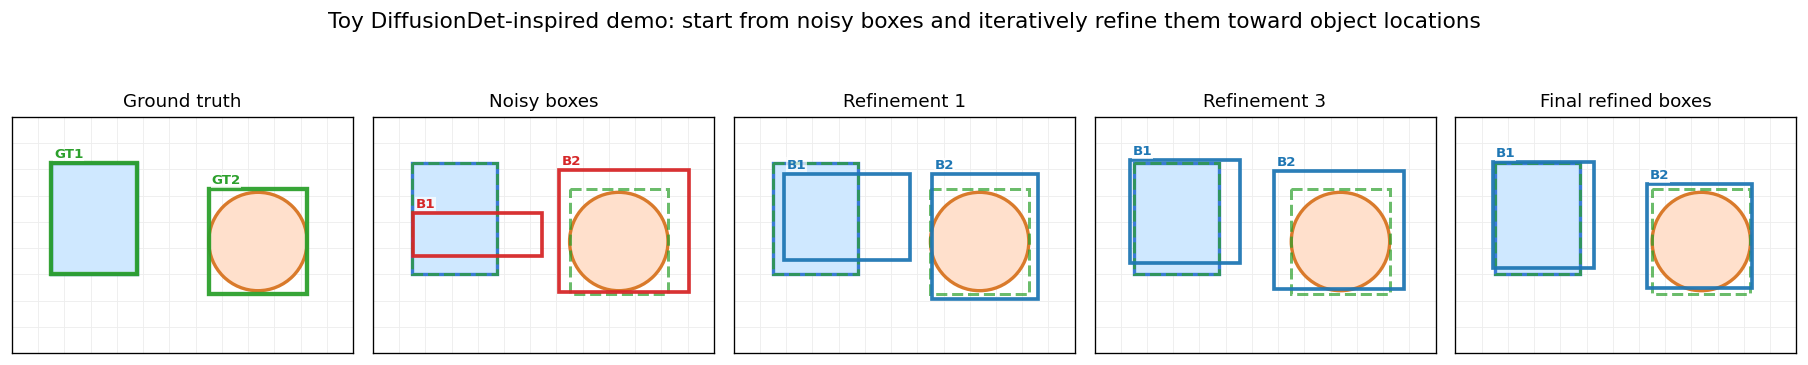

Saved: /content/figures/toy_diffusiondet_refinement.png


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle
from pathlib import Path

# ============================================================
# Toy DiffusionDet-style box refinement demo
# - CPU friendly
# - deterministic
# - no training, just a conceptual simulation
# - shows noisy boxes refined iteratively toward object boxes
# ============================================================

SEED = 11
rng = np.random.default_rng(SEED)

FIG_DIR = Path("figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

IMG_H, IMG_W = 180, 260

# ------------------------------------------------------------
# Synthetic scene
# boxes are [x1, y1, x2, y2]
# ------------------------------------------------------------
gt_boxes = np.array([
    [30, 35, 95, 120],    # rectangle object
    [150, 55, 225, 135],  # circle-ish object
], dtype=float)

def draw_scene(ax):
    ax.set_xlim(0, IMG_W)
    ax.set_ylim(IMG_H, 0)
    ax.set_aspect("equal")
    ax.set_facecolor("white")

    # object 1: filled rectangle
    rect = Rectangle((30, 35), 65, 85, facecolor="#cfe8ff", edgecolor="#3a7bd5", lw=2)
    ax.add_patch(rect)

    # object 2: filled circle
    circ = Circle((187.5, 95), 37.5, facecolor="#ffe0cc", edgecolor="#d97a2b", lw=2)
    ax.add_patch(circ)

    # faint background grid
    for x in range(0, IMG_W + 1, 20):
        ax.plot([x, x], [0, IMG_H], color="0.93", lw=0.5, zorder=0)
    for y in range(0, IMG_H + 1, 20):
        ax.plot([0, IMG_W], [y, y], color="0.93", lw=0.5, zorder=0)

    ax.set_xticks([])
    ax.set_yticks([])

def clip_boxes(boxes):
    boxes = boxes.copy()
    boxes[:, 0] = np.clip(boxes[:, 0], 0, IMG_W - 5)
    boxes[:, 1] = np.clip(boxes[:, 1], 0, IMG_H - 5)
    boxes[:, 2] = np.clip(boxes[:, 2], 5, IMG_W)
    boxes[:, 3] = np.clip(boxes[:, 3], 5, IMG_H)

    # ensure x2 > x1 and y2 > y1
    boxes[:, 2] = np.maximum(boxes[:, 2], boxes[:, 0] + 8)
    boxes[:, 3] = np.maximum(boxes[:, 3], boxes[:, 1] + 8)
    return boxes

def perturb_boxes(boxes, noise_std=26.0):
    noisy = boxes + rng.normal(0.0, noise_std, size=boxes.shape)
    return clip_boxes(noisy)

def refine_boxes_step(boxes, gt_boxes, alpha=0.28, noise_std=6.0):
    """
    One toy 'reverse diffusion' step:
    move each noisy box partway toward the ground-truth box,
    with gradually reduced Gaussian noise.
    """
    boxes = boxes + alpha * (gt_boxes - boxes) + rng.normal(0.0, noise_std, size=boxes.shape)
    return clip_boxes(boxes)

def draw_boxes(ax, boxes, color, lw=2.0, alpha=0.95, linestyle="-", label_prefix=None):
    for i, b in enumerate(boxes):
        x1, y1, x2, y2 = b
        rect = Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            fill=False, edgecolor=color, lw=lw, alpha=alpha, linestyle=linestyle
        )
        ax.add_patch(rect)
        if label_prefix is not None:
            ax.text(
                x1 + 2, max(10, y1 - 4),
                f"{label_prefix}{i+1}",
                color=color, fontsize=8, weight="bold",
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=0.5)
            )

# ------------------------------------------------------------
# Generate refinement trajectory
# ------------------------------------------------------------
initial_boxes = perturb_boxes(gt_boxes, noise_std=28.0)

traj = [initial_boxes.copy()]
boxes = initial_boxes.copy()

# 6 refinement steps
noise_schedule = [10.0, 8.0, 6.0, 4.0, 2.8, 1.5]
for ns in noise_schedule:
    boxes = refine_boxes_step(boxes, gt_boxes, alpha=0.30, noise_std=ns)
    traj.append(boxes.copy())

# choose snapshots to display
snapshots = [
    ("Ground truth", gt_boxes),
    ("Noisy boxes", traj[0]),
    ("Refinement 1", traj[1]),
    ("Refinement 3", traj[3]),
    ("Final refined boxes", traj[-1]),
]

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 5, figsize=(15.2, 3.2))

for ax, (title, boxes_now) in zip(axes, snapshots):
    draw_scene(ax)

    # always show GT lightly for reference except first panel
    if title != "Ground truth":
        draw_boxes(ax, gt_boxes, color="#2ca02c", lw=1.8, alpha=0.7, linestyle="--")

    if title == "Ground truth":
        draw_boxes(ax, gt_boxes, color="#2ca02c", lw=2.6, alpha=0.95, label_prefix="GT")
    elif title == "Noisy boxes":
        draw_boxes(ax, boxes_now, color="#d62728", lw=2.2, alpha=0.95, label_prefix="B")
    else:
        draw_boxes(ax, boxes_now, color="#1f77b4", lw=2.2, alpha=0.95, label_prefix="B")

    ax.set_title(title, fontsize=11)

# global legend-like note
fig.suptitle(
    "Toy DiffusionDet-inspired demo: start from noisy boxes and iteratively refine them toward object locations",
    fontsize=13, y=1.03
)

fig.tight_layout()

out_path = FIG_DIR / "toy_diffusiondet_refinement.png"
fig.savefig(out_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Saved: {out_path.resolve()}")

## 7b) Algorithmic steps: DiffusionDet-style structured prediction

### Training
1. Start from ground-truth bounding boxes.
2. Corrupt the boxes with Gaussian noise.
3. Use image features, noisy boxes, and the timestep to predict refined boxes and class scores.
4. Match predictions to targets and optimize the detection losses.

### Inference
1. Initialize a set of random boxes.
2. Iteratively refine the boxes and class scores.
3. Remove or renew low-confidence boxes during the chain.
4. Output the final refined set of detections.

This is the key classroom point: diffusion is a general iterative refinement mechanism for structured outputs, not only an image generator.


## 8) Slide mapping and wrap-up

A good single-session teaching flow is:

- **start with the story**: `story_diffusion_strip.png`
- **explain the score**: `score_langevin.png`
- **show forward noising**: `forward_noising_moons.png`
- **show the DDPM objective and one tiny training curve**: `ddpm_training_curve.png`
- **show reverse generation**: `reverse_sampling_strip.png`
- **connect to conditional forecasting**: `time_series_samples.png`
- **close with practice constraints**: `speed_quality_tradeoff.png`

### References for lecture preparation

- Ho, Jain, Abbeel (NeurIPS 2020), **DDPM**
- Song et al. (ICLR 2021), **Score-based generative modeling through SDEs**
- Murphy, **Probabilistic Machine Learning: Advanced Topics**
- Hugging Face `diffusers`
- `pyprobml`

The notebook is intentionally small and transparent so it can be used live in class.

## 9) Practice problems for students

### Conceptual questions
1. Why is a diffusion model naturally a distribution model rather than only a point predictor?
2. What is the role of the score $\nabla_x \log p(x)$ in the reverse process?
3. Why can stronger guidance improve condition fidelity while reducing diversity?

### Analytical questions
4. Starting from the one-step forward process, derive the closed-form expression
   $$x_t = \sqrt{\bar\alpha_t}x_0 + \sqrt{1-\bar\alpha_t}\,\epsilon.$$
5. Explain why $\epsilon$-prediction and $x_0$-prediction are two parameterizations of the same denoising problem.
6. In Langevin dynamics, what are the distinct roles of the drift term and the noise term?

### Implementation questions
7. In the fast-sampling experiment, increase the stride and explain what happens to runtime and MMD.
8. In the inpainting demo, enlarge the missing region and describe how the diversity of completions changes.
9. In the forecasting demo, increase the future horizon $H$ and discuss how uncertainty should change.


## 10) Detailed solutions

### 1) Why is diffusion a distribution model rather than only a point predictor?
A diffusion model defines a **stochastic generative process**. During inference we start from a random variable,
$$x_T \sim \mathcal N(0,I),$$
and then apply a sequence of stochastic reverse updates. Because the starting point is random, and because some samplers also inject randomness during the reverse chain, repeated runs do not return one fixed answer. Instead they produce **multiple plausible samples** from an estimated data distribution.

This is fundamentally different from a deterministic regressor, which maps an input to a single output. In uncertainty language, diffusion represents uncertainty through a **sample distribution** rather than only through a point estimate or a scalar variance.

### 2) What is the role of the score $\nabla_x \log p(x)$?
The score tells us the local direction in which log-density increases most rapidly. If a point lies in a low-density region, the score points toward more likely regions of the distribution. In score-based diffusion, this is exactly the information needed to reverse the noising process: the reverse dynamics use the score to decide how to move a noisy sample toward the data manifold.

In the lecture notebook, the Gaussian-mixture example makes this visible. The arrows in the score field point toward high-density modes, and Langevin dynamics combines this deterministic drift with injected noise. This is the conceptual bridge between score estimation and reverse diffusion sampling.

### 3) Why can stronger guidance improve fidelity but reduce diversity?
Classifier or classifier-free guidance adds an extra push toward outputs that satisfy the condition more strongly. For example, in text conditioning this means the sample is pulled harder toward features that match the prompt. As the guidance weight increases, the model spends less probability mass on alternative samples that also fit the condition but differ in style, layout, or details.

So there is a tradeoff:
- **higher guidance** usually improves condition adherence,
- but **lower diversity** means fewer alternative plausible samples.

In uncertainty terms, guidance narrows the effective conditional distribution.

### 4) Derive the closed-form forward process $q(x_t\mid x_0)$
The one-step forward process is
$$x_t = \sqrt{\alpha_t}x_{t-1} + \sqrt{1-\alpha_t}\,\epsilon_t,
\qquad \epsilon_t \sim \mathcal N(0,I).$$
Apply this recursively:
$$x_t = \sqrt{\alpha_t}\,x_{t-1} + \sqrt{1-\alpha_t}\,\epsilon_t,$$
$$x_{t-1} = \sqrt{\alpha_{t-1}}x_{t-2} + \sqrt{1-\alpha_{t-1}}\epsilon_{t-1},$$
and substitute repeatedly until reaching $x_0$. The coefficient multiplying $x_0$ becomes
$$\sqrt{\alpha_t\alpha_{t-1}\cdots \alpha_1} = \sqrt{\bar\alpha_t}.$$
All remaining terms are linear combinations of independent Gaussians, so they are jointly Gaussian with zero mean. Their combined variance becomes
$$1-\bar\alpha_t.$$
Therefore,
$$x_t = \sqrt{\bar\alpha_t}x_0 + \sqrt{1-\bar\alpha_t}\,\epsilon,
\qquad \epsilon \sim \mathcal N(0,I).$$
Equivalently,
$$q(x_t\mid x_0)=\mathcal N\left(\sqrt{\bar\alpha_t}x_0,(1-\bar\alpha_t)I\right).$$

### 5) Why are $\epsilon$-prediction and $x_0$-prediction equivalent parameterizations?
Start from the forward relation
$$x_t = \sqrt{\bar\alpha_t}x_0 + \sqrt{1-\bar\alpha_t}\,\epsilon.$$
If we know $x_t$ and predict $\epsilon$, then we can solve for the clean sample:
$$\hat x_0 = \frac{x_t - \sqrt{1-\bar\alpha_t}\,\hat\epsilon}{\sqrt{\bar\alpha_t}}.$$
Conversely, if we predict $x_0$, then we can solve for the implied noise:
$$\hat\epsilon = \frac{x_t - \sqrt{\bar\alpha_t}\,\hat x_0}{\sqrt{1-\bar\alpha_t}}.$$
So both targets describe the same underlying denoising task. They are not different problems; they are different choices of target variable for training.

### 6) What are the roles of the drift and noise terms in Langevin dynamics?
The Langevin update is
$$x_{k+1}=x_k + \eta\nabla_x\log p(x_k) + \sqrt{2\eta}\,z_k,
\qquad z_k\sim\mathcal N(0,I).$$
The two terms play different roles:
- the **drift term** $\eta\nabla_x\log p(x_k)$ pushes the sample toward higher-density regions;
- the **noise term** $\sqrt{2\eta}\,z_k$ preserves stochastic exploration and prevents the method from becoming pure gradient ascent.

Without the noise term, the procedure would collapse into deterministic hill-climbing toward modes. With both terms together, Langevin dynamics can explore the distribution while still favoring high-density regions.

### 7) What should happen when the fast-sampling stride increases?
Increasing stride means you skip more reverse steps. That reduces runtime because the denoiser is evaluated fewer times. But each reverse step must now remove more noise at once, so sample quality usually degrades. In the notebook this is measured by a simple MMD proxy against reference two-moons data.

Expected outcome:
- stride $\uparrow$  $\Rightarrow$ runtime $\downarrow$
- stride $\uparrow$  $\Rightarrow$ MMD usually $\uparrow$ (worse quality)

This is exactly the practical tension behind DDIM, DPM-Solver, and other fast-sampling methods.

### 8) What should happen when the inpainting mask is enlarged?
A larger missing region means the condition is weaker: the model sees fewer observed pixels and has more freedom in the missing area. Therefore the conditional distribution should become broader, and the sampled completions should become more diverse. In uncertainty language, a weaker condition implies higher posterior uncertainty.

Expected outcome:
- small mask $\Rightarrow$ tighter completions, less diversity
- large mask $\Rightarrow$ more varied completions, wider uncertainty

### 9) What should happen when the forecasting horizon increases?
A longer forecasting horizon means the model must extrapolate further beyond the observed past. Because the future depends on more unknown factors, uncertainty should widen. So we expect a broader spread of sampled futures and larger forecast intervals.

Expected outcome:
- horizon $H \uparrow$  $\Rightarrow$ sample spread $\uparrow$
- horizon $H \uparrow$  $\Rightarrow$ predictive intervals widen

This matches the general idea that predictive uncertainty grows as the model is asked to reason farther away from the observed context.
